# Density method - $\mu$ interpolation

In [13]:
from ngsolve import *
from ngsolve.webgui import Draw
import ngsolve 
ngsolve.SetNumThreads(1)
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.animation as animation
import numpy as np
import imageio
import io

## 1) Geometry

In [14]:
from Geometry import transformer

mesh = transformer(NCoils = 2, hmax=0.005)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## 2) Magnetostatic problem

In [15]:
from Solver import solveMag

nu0 = 1/(4e-7 * pi) 
a0, Kinv = solveMag(nu0, mesh)

Draw(a0, mesh, settings = {"Objects" : { "Wireframe" : False } })

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 3) Objective function & adjoint problem
### a) Objective function

In [16]:
def avgSecondaryFlux(state):
    return Integrate ( state, mesh.Materials("Sp") ) - Integrate ( state, mesh.Materials("Sm") ) 


# we want to maximize the secondary flux = minimize its opposite
def objectiveFunction(state):
    return - avgSecondaryFlux(state)
#Integrate(nu0*nu_f * grad(state) * grad(state), mesh)


print(f" {objectiveFunction(a0) = :.5e} Wb/m")

 objectiveFunction(a0) = -3.87551e-09 Wb/m


### b) Adjoint problem

In [17]:
def objectiveFunctionDD(a, aStar):
    """ Directional derivative of the objective function in the direction aStar """
    return aStar*dx("Sm")  - aStar*dx("Sp")

from Solver import solveAdjoint

p0 = solveAdjoint(Kinv, a0, objectiveFunctionDD)

Draw(p0, mesh, settings = {"Objects" : { "Wireframe" : False } })

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 4) Material interpolation

Even if BESO is a ON-OFF method without intermediate materials, the computation of the derivative still depends on the derivative of the interpolation at $\rho = 0$ and $\rho = 1$.

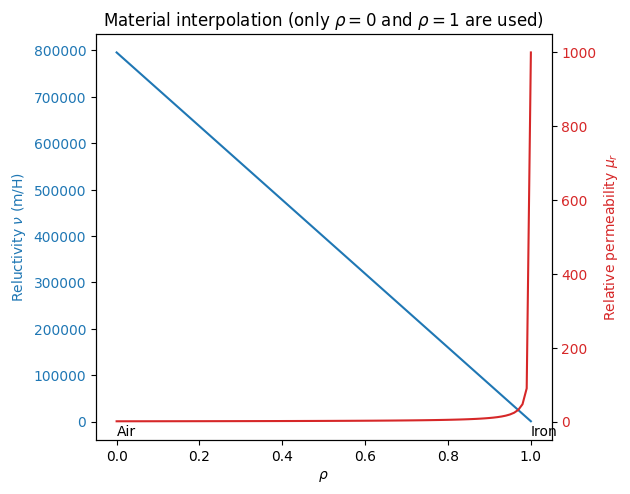

In [18]:
q = 0  # can be changed to add penalization

nu0 = 1/(4e-7*pi)
nu_f = nu0/1000

flagInterp = "nuLinear" 

if flagInterp == "muLinear":         # mu "interpolation" -> unstable
    def rho2nu(rho):
        """ Returns the reluctivity equivalent to a RAMP interpolation of permeability
        q = 0  => linear interpolation of permeability """
        return 1 / ( 1/nu0 + (1/nu_f-1/nu0)*rho/(q-q*rho+1) )  

    def dnu_drho(rho):
        """ Derivative of rho2nu """
        return -(nu0*nu_f*(nu0 - nu_f)*(q + 1))/(nu_f + nu_f*q + nu0*rho - nu_f*rho - nu_f*q*rho)**2

elif flagInterp == "nuLinear":       # nu "interpolation"  ->  stable
    def rho2nu(rho):
        """ Returns RAMP interpolation of reluctivity
        q = 0  => linear interpolation of reluctivity """
        return  nu0 + (nu_f-nu0)*rho/(q-q*rho+1)  

    def dnu_drho(rho):
        """ Derivative of rho2nu """
        return (nu_f-nu0)*(q+1)/(q-q*rho+1)**2

elif flagInterp == "topologicalDerivative":  # theoretical topological derivative -> unstable
    def rho2nu(rho):
        """ Consistent interpolation with topological derivative
         see http://dx.doi.org/10.1109/ICEM51905.2022.9910654"""
        return nu0 + (nu_f - nu0) * (2*nu0/(nu0+nu_f) * rho - (nu0-nu_f)/(nu0+nu_f) * rho**2)
    
    def dnu_drho(rho):
        """ derivative of consistent relaxation that is d0 in 0 and d1 in 1  """
        return (nu_f - nu0) * (2*(nu0 - nu0*rho + nu_f*rho))/(nu0 + nu_f)
    
######## Plot
import matplotlib.pyplot as plt
import numpy as np

r = np.linspace(0,1,100)
fig, ax1 = plt.subplots(); color = 'tab:blue'
ax1.plot(r,rho2nu(r), color = color); ax1.text(0,-3e4,"Air"); ax1.text(1,-3e4,"Iron")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('$\\rho$'); ax1.set_ylabel("Reluctivity $\\nu$ (m/H)", color = color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Relative permeability $\\mu_r$", color=color)
ax2.plot(r, nu0/rho2nu(r), color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title("Material interpolation (only $\\rho = 0$ and $\\rho = 1$ are used)")
plt.show()
########

## 5) Gradient of objective function w.r.t $\rho$

In [19]:
from Solver import Curl

def dobjectiveFunction_drho(rho, state, adjoint):
    return - Curl(adjoint) * (dnu_drho(rho) * Curl(state))

Draw(dobjectiveFunction_drho(0, a0, p0), mesh, settings = {"Objects" : { "Wireframe" : False } })

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

BaseWebGuiScene

## 6) Volume

In [20]:
V0 = Integrate(CF((1)), mesh) # volume of Omega

def volume(rho):
    return Integrate(rho, mesh) / V0

def dvolume_drho(rho):
    """ Scalar field representing the linear form obtained by the directional derivative of the volume 
    The directionnal derivative in the gamma direction reads < dvolume_drho, gamma > """
    return CF((1)) / V0

## 7) Optimization - BESO update

In [21]:
## 7) Optimization - BESO update
from copy import copy
import numpy as np

mask = GridFunction(L2(mesh))
mask.Set(mesh.MaterialCF({"Omega_c" : 1}))
maskOmega_c = mask.vec.FV().NumPy()[:]


In [22]:
# ── Préparer le maillage pour matplotlib ────────────────────
coords    = np.array([v.point for v in mesh.vertices])
triangles = [[v.nr for v in el.vertices] for el in mesh.Elements(VOL)]
triang    = tri.Triangulation(coords[:, 0], coords[:, 1], triangles)

# ── Stocker les frames ───────────────────────────────────────
frames = []
images = []

 It.:    1 | Change: +312 (1564 ajouts, 1252 suppressions) | Objectif: 4.5155 | Surface: 1.07%
 It.:    2 | Change: +279 (1397 ajouts, 1118 suppressions) | Objectif: 13.4608 | Surface: 2.10%
 It.:    3 | Change: +247 (1236 ajouts, 989 suppressions) | Objectif: 37.6886 | Surface: 2.99%
 It.:    4 | Change: +219 (1096 ajouts, 877 suppressions) | Objectif: 3308.2086 | Surface: 3.82%
 It.:    5 | Change: +193 (967 ajouts, 774 suppressions) | Objectif: 4177.3579 | Surface: 4.49%
 It.:    6 | Change: +172 (861 ajouts, 689 suppressions) | Objectif: 4630.1290 | Surface: 5.11%
 It.:    7 | Change: +153 (765 ajouts, 612 suppressions) | Objectif: 4925.3392 | Surface: 5.66%
 It.:    8 | Change: +136 (679 ajouts, 543 suppressions) | Objectif: 5204.3700 | Surface: 6.16%
 It.:    9 | Change: +121 (601 ajouts, 480 suppressions) | Objectif: 5406.6394 | Surface: 6.62%
 It.:   10 | Change: +105 (528 ajouts, 423 suppressions) | Objectif: 5586.1273 | Surface: 7.01%
 It.:   11 | Change: +93 (467 ajouts, 374

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

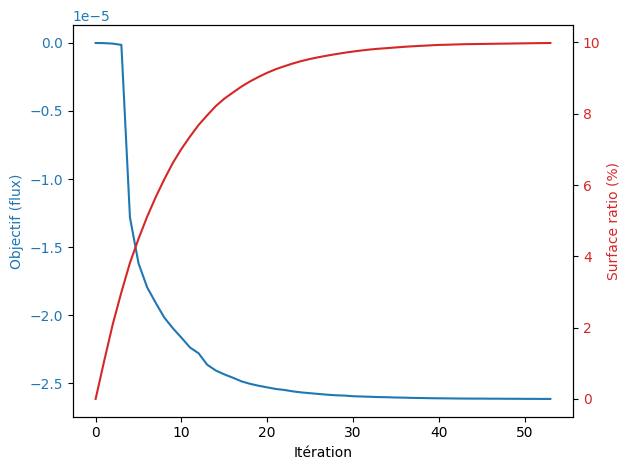

In [ ]:

# ── Fonction sensibilité ─────────────────────────────────────
def compute_sensitivity(rho):
    u, Kinv = solveMag(rho2nu(rho), mesh)
    
    flux_global = objectiveFunction(u)
    
# 2) Solve adjoint
    p = solveAdjoint(Kinv, u, objectiveFunctionDD)
# Gradient de l'objectif par élément = dnu_drho * grad(u) * grad(p)
    grad_elem = Integrate(
        dnu_drho(rho) * grad(u) * grad(p),
        mesh, element_wise=True
    ).NumPy()[:]
    
    #delta_B_elements = sens_Sp - sens_Sm
    delta_B = np.concatenate([[flux_global], grad_elem])
    
    obj = objectiveFunction(u)
    return delta_B, obj

# ── Initialisation ───────────────────────────────────────────
eVol         = Integrate(CF(1), mesh, element_wise=True).NumPy()[:] / V0
list_elemX   = np.where(maskOmega_c.astype(bool))[0]  # indices éléments optimisables
xval         = np.zeros(len(list_elemX))               # 0 = air, 1 = fer

rho = GridFunction(L2(mesh))
rho.vec.FV().NumPy()[:] = 0.0

# Premier calcul FE
delta_B, obj = compute_sensitivity(rho)
initial_energy = delta_B[0]
max_surf = np.sum(eVol[list_elemX])

# ── Paramètres BESO ──────────────────────────────────────────
surf_ratio       = 0.1    # = mass_target
surf_precision   = 0.999
add_precision    = 0.05
remove_precision = 0.05
init_factor      = 0.8
N_max            = 100

modified     = list(range(len(list_elemX)))
current_surf = 0.0
loop         = 0

MemObjective    = []
MemConstraint   = []

# ── Boucle BESO ──────────────────────────────────────────────
while (current_surf < max_surf * surf_ratio * surf_precision or
       current_surf > max_surf * surf_ratio) and loop < N_max:

    MemObjective.append(obj)
    MemConstraint.append(current_surf / max_surf)

    loop += 1
    ratio = abs(current_surf / max_surf / surf_ratio - 1.0)

    # Ajustement init_factor et surf_precision
    if current_surf > max_surf * surf_ratio:
        init_factor    = 1.1
        surf_precision -= 0.1
    if current_surf < max_surf * surf_ratio * surf_precision and init_factor == 1.1:
        init_factor    = 0.9
        surf_precision -= 0.1

    # Nombre d'éléments à modifier
    add_nbr    = round(add_precision    * ratio * len(list_elemX))
    remove_nbr = round(remove_precision * init_factor * ratio * len(list_elemX))

    if add_nbr == remove_nbr:
        if current_surf > max_surf * surf_ratio:
            remove_nbr += 1
        else:
            add_nbr += 1
  # Sensibilité par élément
    sens = delta_B[list_elemX + 1]
        # ── Vectorisé ───────────────────────────────────────────
    modified_mask = np.zeros(len(list_elemX), dtype=bool)
    modified_mask[modified] = True

    # Éléments à AJOUTER : dans modified, tri par sensibilité décroissante
    candidates_add    = np.where( modified_mask)[0]
    candidates_remove = np.where(~modified_mask)[0]

    if add_nbr > 0 and len(candidates_add) > 0:
        top_add = candidates_add[np.argsort(sens[candidates_add])[-add_nbr:]]
        xval[top_add] = 1.0
        modified_mask[top_add] = False  # retirer de modified

    # Éléments à SUPPRIMER : hors modified, tri par sensibilité croissante
    if remove_nbr > 0 and len(candidates_remove) > 0:
        top_remove = candidates_remove[np.argsort(sens[candidates_remove])[:remove_nbr]]
        xval[top_remove] = 0.0
        modified_mask[top_remove] = True   # remettre dans modified

    # Resynchroniser modified
    modified = list(np.where(modified_mask)[0])

    # Mettre à jour rho
    rho.vec.FV().NumPy()[list_elemX] = xval

    # Nouveau calcul FE
    delta_B, obj = compute_sensitivity(rho)
    if initial_energy == 0.0:
        initial_energy = delta_B[0]

    current_surf = np.sum(eVol[list_elemX] * xval)
    
# Sauvegarder la frame
    frames.append(rho.vec.FV().NumPy()[:].copy())
    print(f" It.: {loop:4d}"
          f" | Change: {add_nbr - remove_nbr:+d} ({add_nbr} ajouts, {remove_nbr} suppressions)"
          f" | Objectif: {current_energy / initial_energy:.4f}"
          f" | Surface: {current_surf / max_surf * 100:.2f}%")

## 8) Analysis of the results
u, _ = solveMag(rho2nu(rho), mesh)
print(f"\nRésultats BESO : flux = {avgSecondaryFlux(u):.5e} | vol = {volume(rho)*100:.3f}% | itérations = {loop}")
# Visualisation géométrie optimale
scene = Draw(rho, mesh, settings={"Objects": {"Wireframe": False}})

### Evolution objectif et contrainte
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.plot(MemObjective, color=color)
ax1.set_xlabel('Itération')
ax1.set_ylabel("Objectif (flux)", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot([s * 100 for s in MemConstraint], color=color)
ax2.set_ylabel("Surface ratio (%)", color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.show()



In [24]:
for i, frame in enumerate(frames):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.tripcolor(triang, facecolors=frame, cmap='binary', vmin=0, vmax=1)
    ax.set_aspect('equal')
    ax.set_title(f'Itération {i+1}/{len(frames)}')
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100)
    buf.seek(0)
    images.append(imageio.imread(buf))
    plt.close()

imageio.mimsave('BESO_evolution.gif', images, fps=5)
print("GIF sauvegardé : BESO_evolution.gif")

C:\Users\maya\AppData\Local\Temp\ipykernel_5832\2614551121.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(buf))


GIF sauvegardé : BESO_evolution.gif


In [25]:
# Visualisation géométrie optimale
scene = Draw(rho, mesh, settings={"Objects": {"Wireframe": False}})

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fal…

## 8) Analysis of the results

### a) Quantities of interest

In [26]:
u, _ = solveMag(rho2nu(rho),mesh)
print(f"Results BESO : flux = {avgSecondaryFlux(u) : .5e} | vol = {volume(rho)*100 : .3f} % | iterations = {loop}")

Results BESO : flux =  2.61570e-05 | vol =  9.946 % | iterations = 54


### b) Evolution of the objective function and constraint

NameError: name 'objectiveList' is not defined

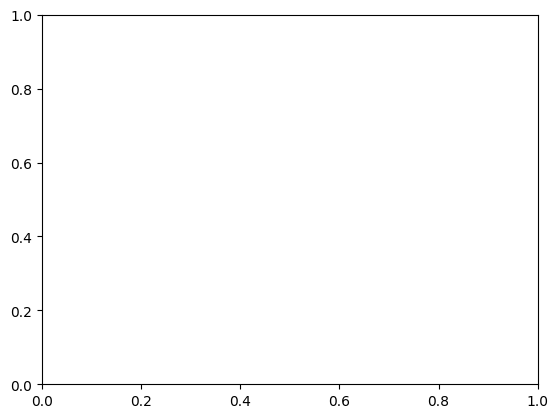

In [27]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(); color = 'tab:blue'
ax1.plot(objectiveList, color = color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('Outer iteration'); ax1.set_ylabel("Objective", color = color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Constraint", color=color)
ax2.plot(constraintList, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.show()